In [233]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical Data Example

In [234]:
df = pd.read_csv("E:/100 Days Machine Learning/Data Sets/train.csv", usecols= ['Age','Fare','Survived'])

In [235]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [236]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [237]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size= 0.2, random_state= 2)

In [238]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [239]:
# Imputing missing values via RandomSampleImputation

x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(148).values

C:\Users\Chirag S\AppData\Local\Temp\ipykernel_19640\2337291511.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(148).values


In [240]:
x_train['Age_imputed'].isnull().sum()

np.int64(0)

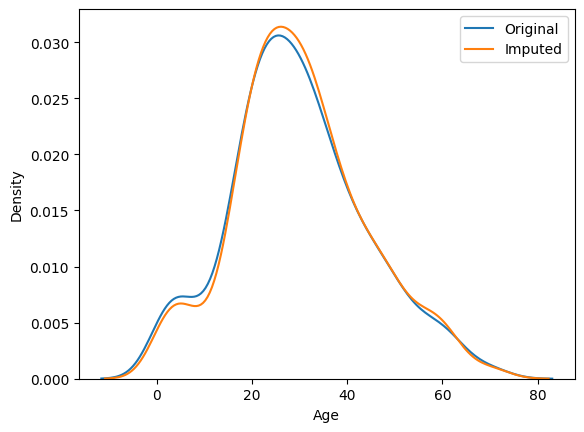

In [241]:
# Distribution of Data

sns.kdeplot(x_train['Age'],label= 'Original')
sns.kdeplot(x_train['Age_imputed'],label= 'Imputed')
plt.legend();

In [242]:
# Variance

print(f"original : {x_train['Age'].var()}")
print(f"Imputed : {x_train['Age_imputed'].var()}")

original : 204.34951339046142
Imputed : 196.6905749630604


In [243]:
# Covariance

x_train.cov()

,Age,Fare,Age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,63.828492
Age_imputed,204.349513,63.828492,196.690575


<Axes: >

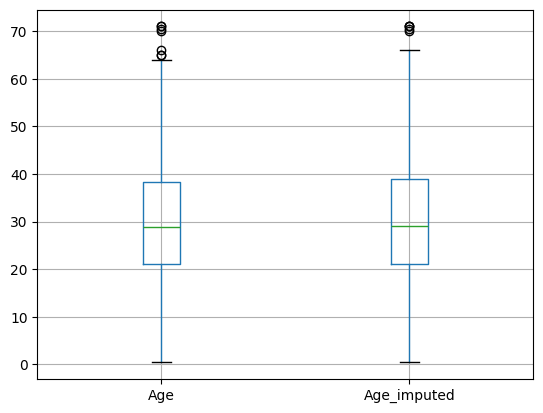

In [244]:
# Outliers

x_train[['Age','Age_imputed']].boxplot()

# Categorical Data Example

In [245]:
df = pd.read_csv("E:/100 Days Machine Learning/Data Sets/house-train.csv", usecols=['GarageQual','FireplaceQu','SalePrice'])

In [246]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [247]:
x = df
y = df['SalePrice']

In [248]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [249]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [250]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

C:\Users\Chirag S\AppData\Local\Temp\ipykernel_19640\4287893096.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['Garage

In [251]:
x_train.sample(10)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
549,Gd,TA,263000,TA,Gd
637,NaN,TA,93000,TA,TA
375,NaN,NaN,61000,TA,TA
1104,NaN,TA,106000,TA,Gd
520,NaN,NaN,106250,TA,TA
4,TA,TA,250000,TA,TA
435,TA,TA,212000,TA,TA
260,TA,TA,176000,TA,TA
978,NaN,TA,110000,TA,Gd
192,NaN,TA,192000,TA,Gd


In [ ]:
# Data isn't changed drastically -> Good Thing
# GarageQual Col

x_train['GarageQual'].value_counts()/len(x_train['GarageQual']), x_train['GarageQual_imputed'].value_counts()/len(x_train['GarageQual'])

(GarageQual
 TA    0.898116
 Fa    0.035103
 Gd    0.009418
 Po    0.000856
 Ex    0.000856
 Name: count, dtype: float64,
 GarageQual_imputed
 TA    0.952055
 Fa    0.035959
 Gd    0.010274
 Po    0.000856
 Ex    0.000856
 Name: count, dtype: float64)

In [264]:
# Data changed drastically -> Bad Thing
# FireplaceQu Col

x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu']), x_train['FireplaceQu_imputed'].value_counts()/len(x_train['FireplaceQu'])

(FireplaceQu
 Gd    0.258562
 TA    0.215753
 Fa    0.021404
 Po    0.014555
 Ex    0.012842
 Name: count, dtype: float64,
 FireplaceQu_imputed
 Gd    0.495719
 TA    0.412671
 Fa    0.039384
 Po    0.028253
 Ex    0.023973
 Name: count, dtype: float64)

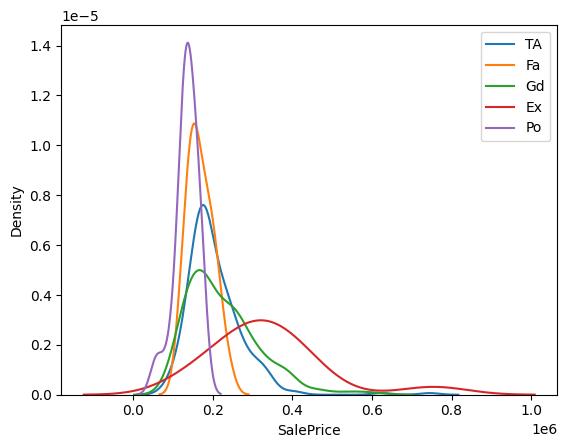

In [265]:
for cat in x_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu'] == cat]['SalePrice'], label = cat)

plt.legend()
plt.show()

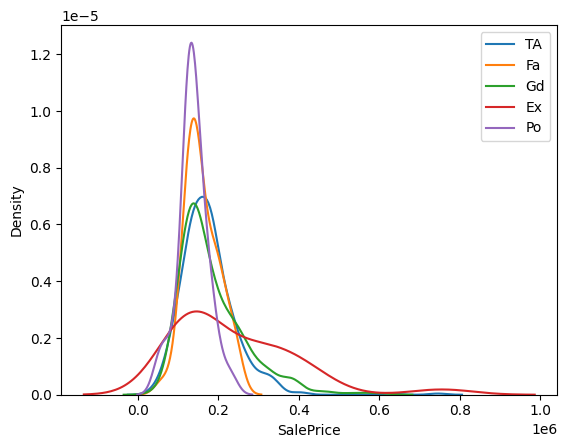

In [266]:
for cat in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu_imputed'] == cat]['SalePrice'], label = cat)

plt.legend()
plt.show()